<div style="
    background-color: #D6EAF8;
    border-radius: 20px;
    padding: 15px;
    text-align: center;
    font-size: 24px;
    font-weight: bold;
    color: #154360;
">
    Importing Required Libraries
</div>


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()

In [3]:
from sklearn.decomposition import PCA
from PIL import Image

<div style="
    background-color: #D5F5E3;
    border-radius: 20px;
    padding: 15px;
    text-align: center;
    font-size: 24px;
    font-weight: bold;
    color: #196F3D;
">
    Load and Resize Image
</div>


In [50]:
img = Image.open('4-Sadie-Sink.jpg')
img.resize((256,256))
img_np = np.array(img)
img_np.shape

(1691, 1200, 3)

## Split RGB Channels

In [5]:
R = img_np[:,:,0]
G = img_np[:,:,1]
B = img_np[:,:,2]

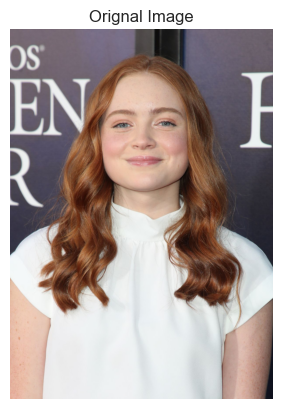

In [6]:
plt.imshow(img_np)
plt.title('Orignal Image')
plt.axis('off')
plt.show()

# 🧠 What is PCA (Principal Component Analysis)?

**PCA** is a statistical technique used to **reduce the number of features (dimensions)** in a dataset while keeping the most important information.

Imagine you have an image with **thousands of pixels**. Not all of them are equally important for understanding the overall picture. PCA helps us:
- Keep the **essential patterns**
- Remove **noise and redundancy**
- Make the data **smaller and faster** to work with

---

### ✨ How Does PCA Work (Simply)?
1. **Starts with your data** (e.g., all pixel values in an image)
2. **Finds the directions of most variation** (called *principal components*)
3. **Projects your data** onto those directions
4. **Keeps only the top components** (e.g., keep 50 out of 3072 features)

✅ End result: Your data is **compressed**, but still meaningful!

---

### 📦 Why Use PCA in This Project?

In our **Image Compression with PCA** project:

- 🖼️ Each image has **thousands of pixel values**
- 📉 We use PCA to **reduce the size** of image data
- 💡 The compressed image still looks **visually similar**
- 🏎️ It’s **faster to store, process, and even classify**

---

### 🚀 Benefits of PCA in Our Project

| Benefit | Explanation |
|--------|-------------|
| 🔻 Reduces Dimensions | Smaller size → less memory usage |
| 💨 Speeds Up Computation | Faster training & processing |
| 🧹 Removes Redundancy | Keeps only meaningful pixel patterns |
| 🧠 Useful for Machine Learning | Can train models on compressed data |
| 🎯 Keeps Visual Quality | Compressed images still look clear |

---

> PCA = Compress + Preserve + Perform ✅  
It’s a powerful tool that bridges **data science and image processing** beautifully.


<div style="
    background-color: #E8DAEF;
    border-radius: 20px;
    padding: 15px;
    text-align: center;
    font-size: 24px;
    font-weight: bold;
    color: #6C3483;
">
    PCA Compression Function
</div>


In [7]:
def compress_channel(channel_data,n_components):
    pca = PCA(n_components = n_components)
    transform = pca.fit_transform(channel_data)
    compressed = pca.inverse_transform(transform)
    return np.clip(compressed,0,255)

In [48]:
n_components = 50   # You can try any numbers of components

R_compressed = compress_channel(R,n_components)
G_compressed = compress_channel(G,n_components)
B_compressed = compress_channel(B,n_components)

compressed_img = np.stack([R_compressed,G_compressed,B_compressed],axis = 2 ).astype(np.uint8)

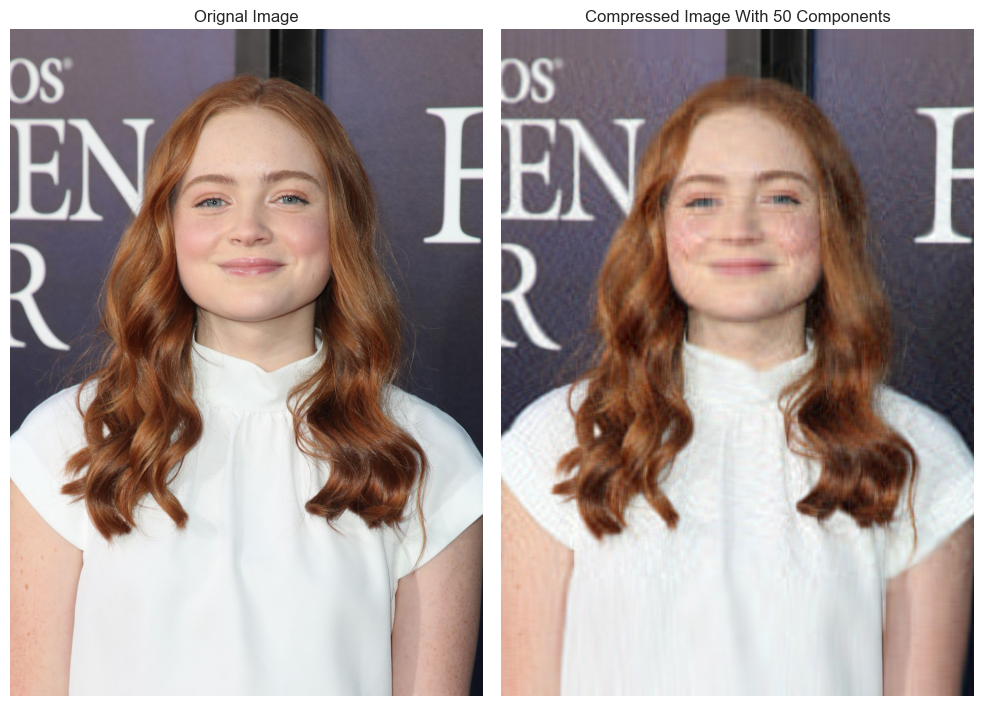

In [9]:
plt.figure(figsize=(10,8))
plt.subplot(1,2,1)
plt.imshow(img_np)
plt.title('Orignal Image')
plt.axis('off')


plt.subplot(1,2,2)
plt.imshow(compressed_img)
plt.title(f'Compressed Image With {n_components} Components')
plt.axis('off')

plt.tight_layout()
plt.show()

<div style="
    background-color: #FDF2E9;
    border-radius: 20px;
    padding: 15px;
    text-align: center;
    font-size: 24px;
    font-weight: bold;
    color: #5D4037;
">
    Loop for Multiple Component Values
</div>

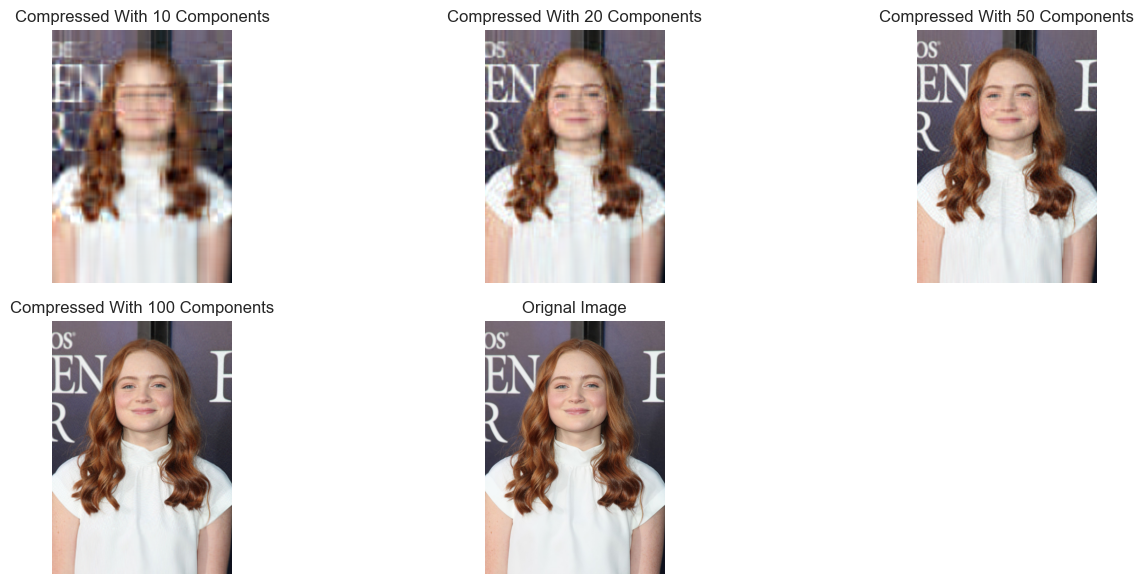

In [62]:
plt.figure(figsize=(14,6))
components = [10,20,50,100]
for i,n in enumerate(components):
    R_com = compress_channel(R,n)
    G_com = compress_channel(G,n)
    B_com = compress_channel(B,n)
    com_img = np.stack([R_com,G_com,B_com],axis=2).astype(np.uint8)
    plt.subplot(2,3,i+1)
    plt.imshow(com_img)
    plt.title(f'Compressed With {n} Components')
    plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(img_np)
plt.title('Orignal Image')
plt.axis('off')
plt.tight_layout()
plt.show()

### 📌 Conclusion: Why Reducing Image Size Matters

Compressing images using **PCA (Principal Component Analysis)** can significantly reduce the **storage size** of image files while keeping most of the **visual quality** intact.

✅ **Benefits of Image Compression**:
- 🗂️ **Saves storage space**, especially when dealing with large datasets or high-resolution images.
- ⚡ **Faster processing and loading** times for machine learning models and web applications.
- 📦 Reduces the cost of **data transfer** and **cloud storage**.
- 🔄 Useful for **real-time systems** or **mobile apps** where bandwidth and memory are limited.

In summary, PCA helps us keep the important visual features while removing redundancy — making our work more efficient, scalable, and optimized. 🎯


<div style="
    background-color: #EBF5FB;
    border-radius: 20px;
    padding: 15px;
    text-align: center;
    font-size: 24px;
    font-weight: bold;
    color: #2E4053;
">
      Thank you <3
</div>